In [1]:
import os
import re
import sys
import subprocess
from collections import defaultdict

import ROOT

ROOT.gROOT.SetBatch(True)
ROOT.TH1.SetDefaultSumw2(True)

# Input directory
INPUT = "root://cmseos.fnal.gov//store/group/lpcmetx/iDMe/Samples/Ntuples/signal_iDMmu_muonBranches_inclusive/2022EE/iDMmu"

TREE_NAME = "ntuples/outT"
BRANCH = "genSigDimuon_dr"

OUTDIR = "genSigDimuon_dr_notebook_plots"
os.makedirs(OUTDIR, exist_ok=True)

Welcome to JupyROOT 6.26/11


In [2]:
def strip_xrootd_path(path):
    if path.startswith("root://"):
        m = re.match(r"^root://[^/]+/(.*)$", path)
        if m:
            return "/" + m.group(1).lstrip("/")
    return path


def xrootd_prefix_from_path(path):
    if path.startswith("root://"):
        m = re.match(r"^(root://[^/]+)", path)
        if m:
            return m.group(1)
    return "root://cmseos.fnal.gov"


def list_root_files(input_path):
    if input_path.endswith(".root"):
        return [input_path]

    if input_path.startswith("root://") or input_path.startswith("/store/"):
        xrd_prefix = xrootd_prefix_from_path(input_path)
        eos_path = strip_xrootd_path(input_path)

        cmd = ["xrdfs", xrd_prefix, "ls", "-R", eos_path]
        output = subprocess.check_output(cmd, text=True, stderr=subprocess.STDOUT)

        files = []
        for line in output.splitlines():
            line = line.strip()
            if line.endswith(".root"):
                if line.startswith("/store/"):
                    files.append(f"{xrd_prefix}/{line}")
                else:
                    files.append(line)

        return sorted(set(files))

    if os.path.isdir(input_path):
        files = []
        for root, _, filenames in os.walk(input_path):
            for fname in filenames:
                if fname.endswith(".root"):
                    files.append(os.path.join(root, fname))
        return sorted(files)

    raise RuntimeError(f"Cannot interpret input path: {input_path}")


def sample_name_from_path(path):
    basename = os.path.basename(path)

    m = re.search(r"(Mchi-[^_/]+_dMchi-[^_/]+_ctau-[^_/\.]+)", basename)
    if m:
        return m.group(1)

    for piece in path.split("/"):
        m = re.search(r"(Mchi-[^_/]+_dMchi-[^_/]+_ctau-[^_/\.]+)", piece)
        if m:
            return m.group(1)

    return "unknown_sample"


def parse_sample(sample):
    m = re.match(r"(Mchi-[^_]+_dMchi-[^_]+)_ctau-([^_]+)", sample)
    if not m:
        return sample, "unknown"
    return m.group(1), m.group(2)


def sample_sort_key(sample):
    m = re.search(r"Mchi-([^_]+)_dMchi-([^_]+)_ctau-([^_]+)", sample)
    if not m:
        return (9999, 9999, 9999)

    def conv(x):
        return float(x.replace("p", "."))

    return conv(m.group(1)), conv(m.group(2)), conv(m.group(3))


def make_chain(files, tree_name=TREE_NAME):
    ch = ROOT.TChain(tree_name)
    for f in files:
        ch.Add(f)
    return ch

In [3]:
files = list_root_files(INPUT)

sample_to_files = defaultdict(list)
for f in files:
    sample = sample_name_from_path(f)
    sample_to_files[sample].append(f)

samples = sorted(sample_to_files.keys(), key=sample_sort_key)

print(f"Found {len(files)} ROOT files")
print(f"Found {len(samples)} grouped samples")

for s in samples:
    print(f"{s:35s}  nfiles = {len(sample_to_files[s])}")

Found 138 ROOT files
Found 20 grouped samples
Mchi-5p25_dMchi-0p5_ctau-1           nfiles = 8
Mchi-5p25_dMchi-0p5_ctau-10          nfiles = 8
Mchi-5p25_dMchi-0p5_ctau-100         nfiles = 8
Mchi-5p25_dMchi-0p5_ctau-1000        nfiles = 5
Mchi-10p5_dMchi-1p0_ctau-1           nfiles = 8
Mchi-10p5_dMchi-1p0_ctau-10          nfiles = 4
Mchi-10p5_dMchi-1p0_ctau-100         nfiles = 4
Mchi-10p5_dMchi-1p0_ctau-1000        nfiles = 7
Mchi-21p0_dMchi-2p0_ctau-1           nfiles = 7
Mchi-21p0_dMchi-2p0_ctau-10          nfiles = 8
Mchi-21p0_dMchi-2p0_ctau-100         nfiles = 7
Mchi-21p0_dMchi-2p0_ctau-1000        nfiles = 8
Mchi-31p5_dMchi-3p0_ctau-1           nfiles = 6
Mchi-31p5_dMchi-3p0_ctau-10          nfiles = 6
Mchi-31p5_dMchi-3p0_ctau-100         nfiles = 7
Mchi-31p5_dMchi-3p0_ctau-1000        nfiles = 8
Mchi-42p0_dMchi-4p0_ctau-1           nfiles = 6
Mchi-42p0_dMchi-4p0_ctau-10          nfiles = 8
Mchi-42p0_dMchi-4p0_ctau-100         nfiles = 7
Mchi-42p0_dMchi-4p0_ctau-1000        nfile

In [58]:
ROOT.gStyle.SetOptStat(0)

# Histogram settings
# x-axis: 0 to 1.5
# bin width: 0.1
NBINS = 30
XMIN = 0.0
XMAX = 1.5
NORMALIZE = True

# Use ROOT colors/styles
colors = [
    ROOT.kBlack,
    ROOT.kRed + 1,
    ROOT.kBlue + 1,
    ROOT.kGreen + 2,
    ROOT.kMagenta + 1,
    ROOT.kCyan + 2,
    ROOT.kOrange + 7,
    ROOT.kViolet + 1,
    ROOT.kTeal + 2,
    ROOT.kPink + 7,
]

line_styles = [1, 2, 3, 4, 5]


def pretty_sample_label(sample):
    """
    Example:
      Mchi-10p5_dMchi-1p0_ctau-100
    becomes:
      m_{#chi}=10.5, #Delta m_{#chi}=1.0, c#tau=100 mm

    Important:
      Use ROOT TLatex-style strings, not Unicode χ/Δ/τ.
    """
    m = re.search(r"Mchi-([^_]+)_dMchi-([^_]+)_ctau-([^_]+)", sample)
    if not m:
        return sample

    mchi = m.group(1).replace("p", ".")
    dmchi = m.group(2).replace("p", ".")
    ctau = m.group(3).replace("p", ".")

    return f"m_{{#chi}}={mchi}, #Delta m_{{#chi}}={dmchi}, c#tau={ctau} mm"


def pretty_mass_label(sample):
    """
    Example:
      Mchi-10p5_dMchi-1p0_ctau-100
    becomes:
      m_{#chi}=10.5, #Delta m_{#chi}=1.0
    """
    m = re.search(r"Mchi-([^_]+)_dMchi-([^_]+)_ctau-([^_]+)", sample)
    if not m:
        return sample

    mchi = m.group(1).replace("p", ".")
    dmchi = m.group(2).replace("p", ".")

    return f"m_{{#chi}}={mchi}, #Delta m_{{#chi}}={dmchi}"


def pretty_ctau_label(sample):
    """
    Example:
      Mchi-10p5_dMchi-1p0_ctau-100
    becomes:
      c#tau=100 mm
    """
    m = re.search(r"_ctau-([^_]+)", sample)
    if not m:
        return sample

    ctau = m.group(1).replace("p", ".")
    return f"c#tau={ctau} mm"

In [59]:
hists = {}
summary = []

for idx, sample in enumerate(samples):
    chain = make_chain(sample_to_files[sample])

    hist_name = "h_" + re.sub(r"[^a-zA-Z0-9_]", "_", sample)

    h = ROOT.TH1F(
        hist_name,
        sample,
        NBINS,
        XMIN,
        XMAX,
    )

    h.Sumw2()

    cut = "GenSigDimuon_isValid"
    expr = f"{BRANCH}>>{hist_name}"

    n_drawn = chain.Draw(expr, cut, "goff")

    color = colors[idx % len(colors)]
    style = line_styles[(idx // len(colors)) % len(line_styles)]

    h.SetStats(False)
    h.SetLineColor(color)
    h.SetMarkerColor(color)
    h.SetLineStyle(style)
    h.SetLineWidth(2)

    if NORMALIZE and h.Integral() > 0:
        h.Scale(1.0 / h.Integral())

    hists[sample] = h

    summary.append(
        {
            "sample": sample,
            "entries": int(chain.GetEntries()),
            "drawn": int(n_drawn),
            "mean": h.GetMean(),
            "rms": h.GetRMS(),
            "underflow": h.GetBinContent(0),
            "overflow": h.GetBinContent(h.GetNbinsX() + 1),
        }
    )

for row in summary:
    print(
        f"{row['sample']:35s} "
        f"entries={row['entries']:8d} "
        f"drawn={row['drawn']:8d} "
        f"mean={row['mean']:.4f} "
        f"rms={row['rms']:.4f} "
        f"overflow={row['overflow']:.4f}"
    )

Mchi-5p25_dMchi-0p5_ctau-1          entries=   30000 drawn=   30000 mean=0.1559 rms=0.1568 overflow=0.0009
Mchi-5p25_dMchi-0p5_ctau-10         entries=   30000 drawn=   30000 mean=0.1567 rms=0.1583 overflow=0.0009
Mchi-5p25_dMchi-0p5_ctau-100        entries=   30000 drawn=   30000 mean=0.1593 rms=0.1601 overflow=0.0008
Mchi-5p25_dMchi-0p5_ctau-1000       entries=   15000 drawn=   15000 mean=0.1595 rms=0.1618 overflow=0.0007
Mchi-10p5_dMchi-1p0_ctau-1          entries=   30000 drawn=   30000 mean=0.3382 rms=0.2960 overflow=0.0418
Mchi-10p5_dMchi-1p0_ctau-10         entries=   10000 drawn=   10000 mean=0.3426 rms=0.2988 overflow=0.0431
Mchi-10p5_dMchi-1p0_ctau-100        entries=   10000 drawn=   10000 mean=0.3369 rms=0.2950 overflow=0.0447
Mchi-10p5_dMchi-1p0_ctau-1000       entries=   25000 drawn=   25000 mean=0.3394 rms=0.2966 overflow=0.0411
Mchi-21p0_dMchi-2p0_ctau-1          entries=   25000 drawn=   25000 mean=0.5131 rms=0.3606 overflow=0.1616
Mchi-21p0_dMchi-2p0_ctau-10         e

Warning in <TROOT::Append>: Replacing existing TH1: h_Mchi_5p25_dMchi_0p5_ctau_1 (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h_Mchi_5p25_dMchi_0p5_ctau_10 (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h_Mchi_5p25_dMchi_0p5_ctau_100 (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h_Mchi_5p25_dMchi_0p5_ctau_1000 (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h_Mchi_10p5_dMchi_1p0_ctau_1 (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h_Mchi_10p5_dMchi_1p0_ctau_10 (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h_Mchi_10p5_dMchi_1p0_ctau_100 (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h_Mchi_10p5_dMchi_1p0_ctau_1000 (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h_Mchi_21p0_dMchi_2p0_ctau_1 (Potential memory leak).
Warning in <TROOT::Append>: Replac

In [60]:
def draw_overlay(
    hist_items,
    title,
    outname,
    label_func=pretty_sample_label,
    legend_title=None,
    logy=False,
    legend_x1=0.68,
    legend_y1=0.12,
    legend_x2=0.99,
    legend_y2=0.90,
    legend_text_size=0.022,
    canvas_width=1200,
    canvas_height=850,
):
    c = ROOT.TCanvas("c_" + outname, "", canvas_width, canvas_height)

    # Leave space for legend on the right
    c.SetRightMargin(0.34)
    c.SetLeftMargin(0.12)
    c.SetBottomMargin(0.12)
    c.SetTopMargin(0.08)

    if logy:
        c.SetLogy()

    leg = ROOT.TLegend(legend_x1, legend_y1, legend_x2, legend_y2)
    leg.SetBorderSize(0)
    leg.SetFillStyle(0)
    leg.SetTextSize(legend_text_size)

    if legend_title is not None:
        leg.SetHeader(legend_title, "C")

    first = True

    for label, h in hist_items:
        h.SetStats(False)
        h.SetTitle(title)

        h.GetXaxis().SetTitle("#DeltaR(#mu^{+}, #mu^{-})")
        h.GetYaxis().SetTitle("Fraction of events / 0.1" if NORMALIZE else "Events / 0.1")

        h.GetXaxis().SetRangeUser(0.0, 1.5)

        h.GetXaxis().SetTitleSize(0.045)
        h.GetYaxis().SetTitleSize(0.045)
        h.GetXaxis().SetLabelSize(0.040)
        h.GetYaxis().SetLabelSize(0.040)

        h.GetYaxis().SetTitleOffset(1.25)

        if logy:
            h.SetMinimum(1e-5)
           
        else:
            h.SetMinimum(0.0)
            

        h.Draw("hist" if first else "hist same")
        leg.AddEntry(h, label_func(label), "l")

        first = False

    leg.Draw()

    png = os.path.join(OUTDIR, outname + ".png")
    pdf = os.path.join(OUTDIR, outname + ".pdf")

    c.SaveAs(png)
    c.SaveAs(pdf)

    return c

Warning in <TCanvas::Constructor>: Deleting canvas with same name: c_genSigDimuon_dr_allSamples_overlay
Info in <TCanvas::Print>: png file genSigDimuon_dr_notebook_plots/genSigDimuon_dr_allSamples_overlay.png has been created
Info in <TCanvas::Print>: pdf file genSigDimuon_dr_notebook_plots/genSigDimuon_dr_allSamples_overlay.pdf has been created


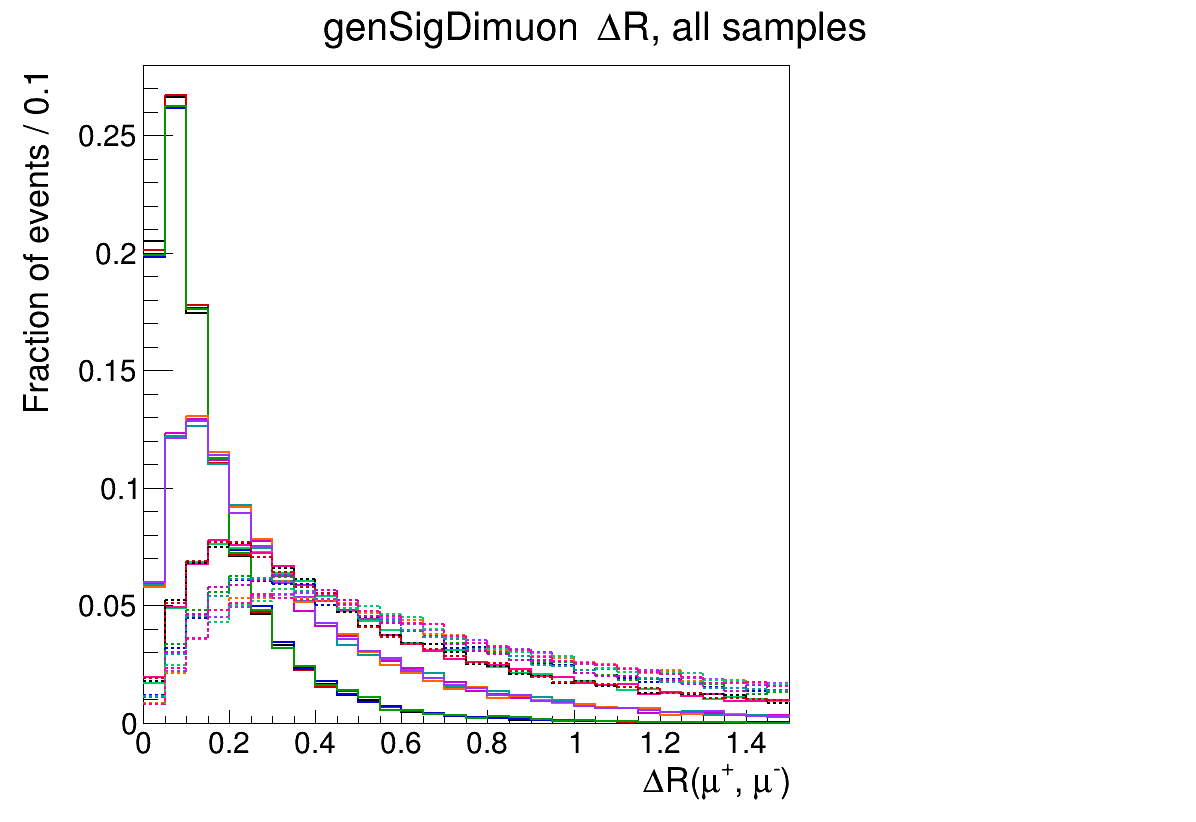

In [61]:
all_items = [(s, hists[s]) for s in samples]

c_all = draw_overlay(
    all_items,
    "genSigDimuon #DeltaR, all samples",
    "genSigDimuon_dr_allSamples_overlay",
    label_func=pretty_sample_label,
    legend_title="Signal samples",
    logy=False,
    legend_text_size=0.018,
)

c_all.Draw()

Info in <TCanvas::Print>: png file genSigDimuon_dr_notebook_plots/genSigDimuon_dr_by_ctau_1.png has been created
Info in <TCanvas::Print>: pdf file genSigDimuon_dr_notebook_plots/genSigDimuon_dr_by_ctau_1.pdf has been created
Info in <TCanvas::Print>: png file genSigDimuon_dr_notebook_plots/genSigDimuon_dr_by_ctau_10.png has been created
Info in <TCanvas::Print>: pdf file genSigDimuon_dr_notebook_plots/genSigDimuon_dr_by_ctau_10.pdf has been created
Info in <TCanvas::Print>: png file genSigDimuon_dr_notebook_plots/genSigDimuon_dr_by_ctau_100.png has been created
Info in <TCanvas::Print>: pdf file genSigDimuon_dr_notebook_plots/genSigDimuon_dr_by_ctau_100.pdf has been created
Info in <TCanvas::Print>: png file genSigDimuon_dr_notebook_plots/genSigDimuon_dr_by_ctau_1000.png has been created
Info in <TCanvas::Print>: pdf file genSigDimuon_dr_notebook_plots/genSigDimuon_dr_by_ctau_1000.pdf has been created


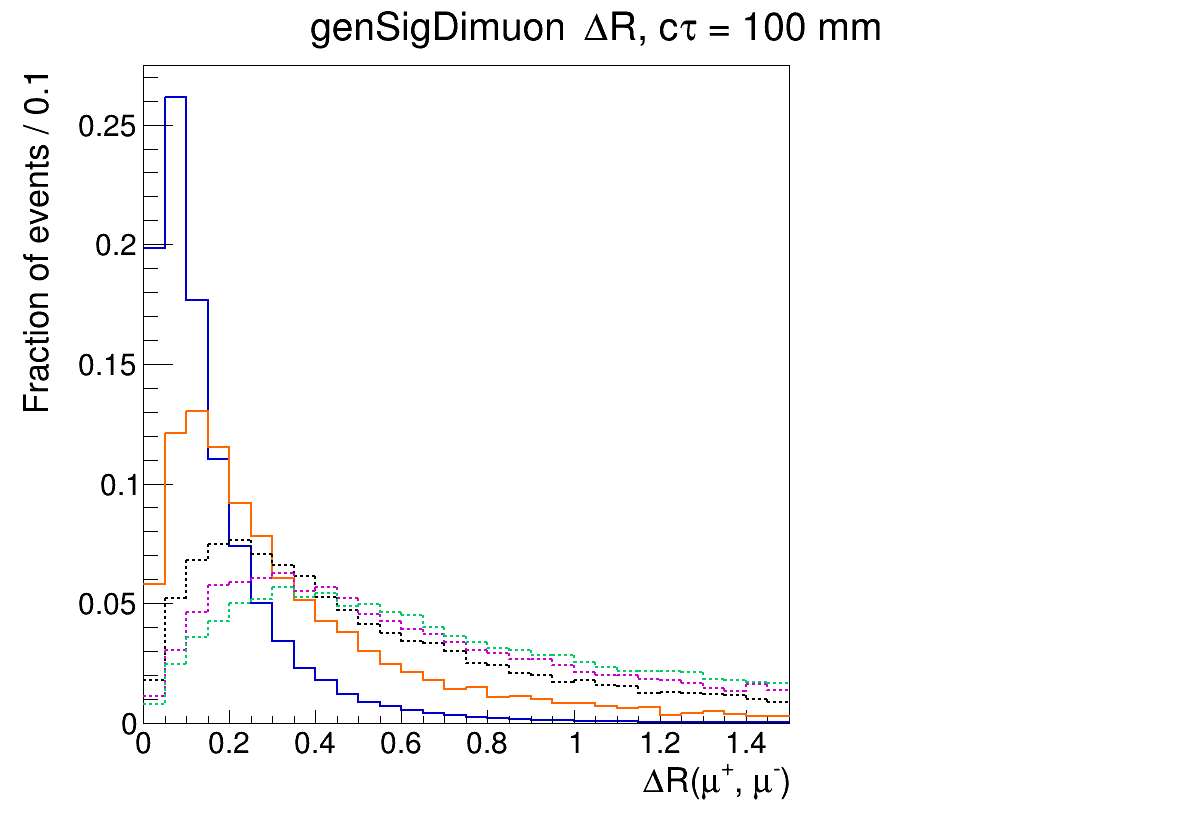

In [62]:
ctau_to_samples = defaultdict(list)

for sample in samples:
    mass_key, ctau = parse_sample(sample)
    ctau_to_samples[ctau].append(sample)

canvases_by_ctau = {}

for ctau in sorted(ctau_to_samples.keys(), key=lambda x: float(x.replace("p", "."))):
    items = [(s, hists[s]) for s in sorted(ctau_to_samples[ctau], key=sample_sort_key)]

    safe_ctau = re.sub(r"[^a-zA-Z0-9_]", "_", ctau)

    canvases_by_ctau[ctau] = draw_overlay(
        items,
        f"genSigDimuon #DeltaR, c#tau = {ctau} mm",
        f"genSigDimuon_dr_by_ctau_{safe_ctau}",
        label_func=pretty_mass_label,
        legend_title="Mass points",
        logy=False,
        legend_x1=0.70,
        legend_y1=0.58,
        legend_x2=0.99,
        legend_y2=0.88,
        legend_text_size=0.027,
    )

# Display one
canvases_by_ctau["100"].Draw()

In [63]:
owd

NameError: name 'owd' is not defined

In [64]:
pwd

'/uscms_data/d3/abdelham/CMSSW_13_0_13/src/iDMe/python_analysis'